

## 六、核心总结
1.  **关联规则 vs 相关系数**：相关系数只能说明“有关系”，而关联规则能明确“谁影响谁、影响多大”，更适合业务决策。
2.  **三度的选择**：
    - 支持度：保证规则有普遍性。
    - 可信度：保证规则有强度。
    - 提升度：保证推荐有价值（lift>1才推荐）。
3.  **Apriori全流程**：
    - 数据探索 → 生成购物篮 → 挖掘关联规则 → 筛选互补/互斥品 → 业务化推荐。
4.  **业务价值**：
    - 货架布局：互补品相邻，互斥品远离。
    - 智能推荐：根据不同业务目标（响应率/销售额）选择不同推荐策略。
    - 商品管理：识别替代品，优化商品结构。

---


## 一、推荐算法与购物篮分析
### 10.1 常见推荐算法
| 分类 | 代表算法 | 适用场景 |
|------|----------|----------|
| 基于客户需求 | 逻辑回归、决策树 | 预测用户是否购买某类商品 |
| 基于购物篮 | **关联规则（Apriori）** | 发现商品间的互补/互斥关系 |
| 基于物品相似性 | ItemCF协同过滤 | 推荐“买过此商品的人还买了” |
| 基于用户相似性 | UserCF协同过滤、KNN | 推荐“相似用户喜欢的商品” |
| 基于内容 | 关联规则、SVD | 基于商品属性推荐 |
| 市场细分 | K-Means | 划分用户群体后精准营销 |

### 10.2 购物篮分析核心概念
- **购物篮**：单个客户一次购买的商品集合（即消费小票）。
- **核心目标**：发现商品间的**互补品**（一起买，如羽毛球拍+羽毛球）和**互斥品**（替代买，如电子书+纸质书）。
- **关联关系分类**：
  - **强关联**：双向关联（剃须刀+剃须膏）或单向关联（大瓶可乐+纸杯）。
  - **弱关联**：尝试摆放后观察销量变化。
  - **排斥关系**：尽量不陈列在一起。



## 二、关联规则与“关联三度”
### 10.3.1 关联三度（核心指标）
关联规则形如 **A → B**（购买A后倾向购买B），用三个指标衡量：

| 指标 | 公式 | 通俗理解 | 业务意义 |
|------|------|----------|----------|
| **支持度(Support)** | `(同时包含A和B的交易数 / 总交易数) × 100%` | 有多少顾客会同时买A和B | 反映规则的**普遍性**，太低则无推广价值 |
| **可信度(Confidence)** | `(同时包含A和B的交易数 / 包含A的交易数) × 100%` | 买了A的顾客中，有多少人又买了B | 反映规则的**强度**，是条件概率P(B\|A) |
| **提升度(Lift)** | `可信度 / (商品B在总交易中的出现频率) × 100%` | 推荐B后，购买概率是自然购买的多少倍 | 衡量推荐的**价值**：<br>• `lift > 1`：推荐有效（互补品）<br>• `lift = 1`：推荐无意义<br>• `lift < 1`：推荐有害（互斥品） |

> ⚠️ 关键反例：“牛肉→米饭”可信度67%，但米饭本身购买率80%，`lift=0.67/0.8<1`，推荐毫无意义。

### 10.3.2 Apriori算法原理
- **核心思想**：
  1.  先找出所有**频繁项集**（满足最小支持度的商品组合）。
  2.  从频繁项集中生成关联规则，筛选满足最小可信度的规则。
- **关键性质**：如果一个项集是频繁的，那么它的所有子集也一定是频繁的（避免无效计算）。


## 三、Python实现Apriori算法
### 10.4.1 数据探索

In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体支持
plt.rc('font',**{'family':'Microsoft YaHei,SimHei'})

df = pd.read_csv('bike_data.csv',encoding='gbk')
df.info();df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52761 entries, 0 to 52760
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   OrderNumber  52761 non-null  object
 1   LineNumber   52761 non-null  int64 
 2   Model        52761 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


,OrderNumber,LineNumber,Model
0,cumid51178,1,山地英骑
1,cumid51178,2,山地车水壶架
2,cumid51178,3,运动水壶
3,cumid51184,1,山地英骑
4,cumid51184,2,hl山地外胎


查看顾客和商品种类的数量

In [18]:
print(f'数据集中共有{df["Model"].nunique()}种商品')
print(f'数据集中共有{df["OrderNumber"].unique()}个顾客')

model_names = df['Model'].unique()
print('商品名分别为:')
for i in range(0,len(model_names),5):
    print(model_names[i:i+5])

数据集中共有37种商品
数据集中共有['cumid51178' 'cumid51184' 'cumid51181' ... 'cumid74135' 'cumid74143'
 'cumid74103']个顾客
商品名分别为:
['山地英骑' '山地车水壶架' '运动水壶' 'hl山地外胎' '山地车内胎']
['运动型头盔' '普通公路车' '公路车内胎' 'hl公路外胎' '竞速公路车']
['公路车水壶架' '长袖骑车衣' '山地车挡泥板' '自行车帽' '山地车400']
['ml山地外胎' '修补工具' '山地车500' '公路车550' '短袖经典车衣']
['旅游型自行车(大)' '竞速袜' '半掌手套' '公路车350' 'ml公路外胎']
['水壶包' '旅游型自行车(小)' '旅游型自行车(中)' '旅游车内胎' 'll公路车外胎']
['旅游自行车外胎(通用)' '万能自行车座' '洗车喷剂' '经典背心' 'll山地胎']
['故障栓钩' "Women's Mountain Shorts"]


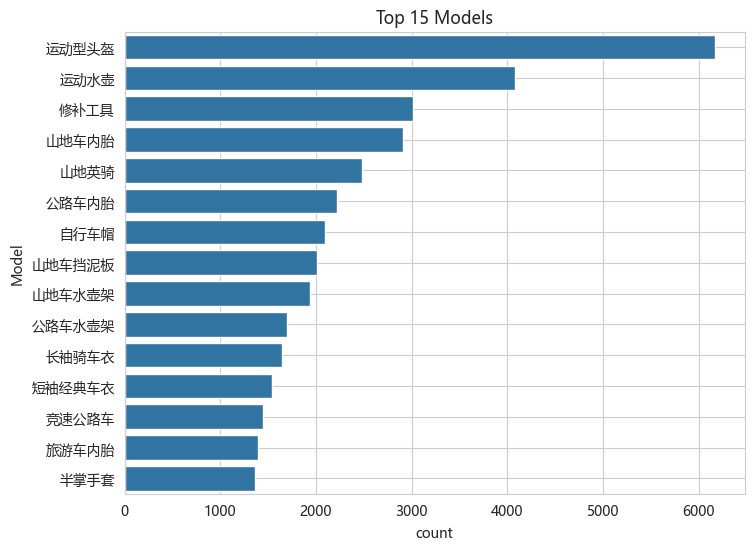

In [19]:
# 查看最畅销的15种商品并可视化
grouped = df.groupby('Model')['Model'].count().reset_index(name = 'count')
top_15 = grouped.sort_values(by = 'count', ascending = False).head(15)
plt.figure(figsize = (8,6))
sns.barplot(data = top_15, x = 'count', y = 'Model')
plt.grid(True)
plt.title('Top 15 Models')
plt.show()

### 2.生成购物篮与关联规则

In [20]:
import Apriori as apri

baskets =apri.dataconvert(
    arulesdata=df,
    tidvar='OrderNumber',# 购物篮的表示(客户ID)
    itemvar='Model',# 放入篮子的商品
    data_type='inverted'
)

# 购物篮个数刚好等于数据集中的客户数量
print(f'购物篮数量:{len(baskets)}')
print(f'客户数量:{df["OrderNumber"].nunique()}')

#预览前五个购物篮中的物品
baskets[:5]

inverted index type dataSet
购物篮数量:21255
客户数量:21255


[['普通公路车', '公路车水壶架'],
 ['运动型头盔', '旅游型自行车(中)'],
 ['山地英骑', '山地车水壶架', '运动水壶'],
 ['万能自行车座', '公路车内胎', 'hl公路外胎', '普通公路车'],
 ['普通公路车', '公路车水壶架', '运动水壶', '运动型头盔', '长袖骑车衣']]

生成关联规则：

In [21]:
result = apri.arules(
    dataset = baskets,
    minSupport = 0.01,# 最小支持度
    minConf = 0.1,#最小可信度
    minlen = 1,
    maxlen=2# 只考虑两个商品的规则
)
result.head(2)

frozenset({'ll山地胎'}) --> frozenset({'山地车内胎'}) conf: 0.560700876095119
frozenset({'山地车内胎'}) --> frozenset({'ll山地胎'}) conf: 0.15405777166437415
frozenset({'旅游自行车外胎(通用)'}) --> frozenset({'修补工具'}) conf: 0.24404086265607264
frozenset({'旅游车内胎'}) --> frozenset({'修补工具'}) conf: 0.25912670007158195
frozenset({'修补工具'}) --> frozenset({'旅游车内胎'}) conf: 0.12026578073089701
frozenset({'ml公路外胎'}) --> frozenset({'修补工具'}) conf: 0.2898876404494382
frozenset({'洗车喷剂'}) --> frozenset({'修补工具'}) conf: 0.3067129629629629
frozenset({'修补工具'}) --> frozenset({'ml山地外胎'}) conf: 0.106312292358804
frozenset({'ml山地外胎'}) --> frozenset({'修补工具'}) conf: 0.29547553093259465
frozenset({'公路车350'}) --> frozenset({'运动型头盔'}) conf: 0.3358449946178687
frozenset({'hl公路外胎'}) --> frozenset({'修补工具'}) conf: 0.2699004975124378
frozenset({'半掌手套'}) --> frozenset({'运动水壶'}) conf: 0.23037417461482027
frozenset({'长袖骑车衣'}) --> frozenset({'山地车挡泥板'}) conf: 0.14494518879415347
frozenset({'山地车挡泥板'}) --> frozenset({'长袖骑车衣'}) conf: 0.1181727904667328

,lhs,,rhs,support,confidence,lift
0,(ll山地胎),==>,(山地车内胎),0.021077,0.560701,4.098245
1,(山地车内胎),==>,(ll山地胎),0.021077,0.154058,4.098245


- **结果字段**：
  - `lhs`：左规则（已购商品，如“山地车内胎”）
  - `rhs`：右规则（推荐商品，如“II山地胎”）
  - `support`：支持度
  - `confidence`：可信度
  - `lift`：提升度

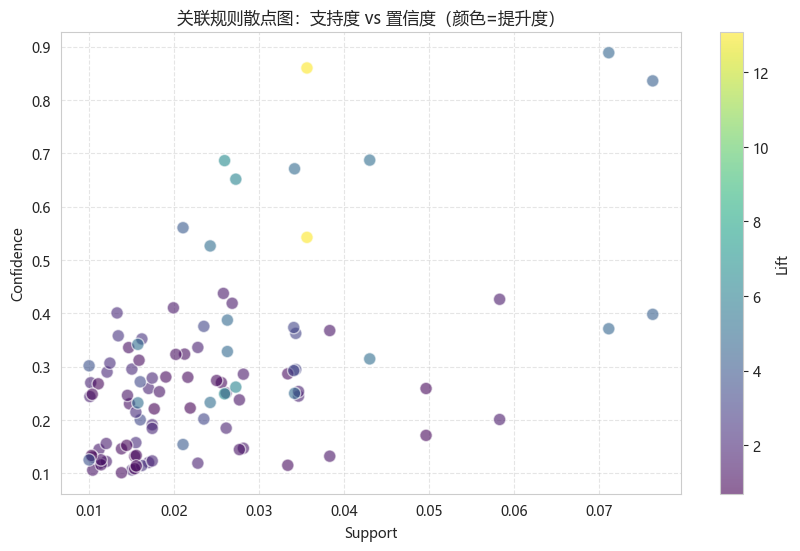

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    result['support'],
    result['confidence'],
    c=result['lift'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='w',
    s=80
)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('关联规则散点图：支持度 vs 置信度（颜色=提升度）')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 关联规则散点图分析（支持度 vs 置信度 vs 提升度）
这张图是**关联规则挖掘结果的可视化**，三个核心指标分别对应：
- **横轴（Support）**：支持度，代表规则在数据中出现的频率
- **纵轴（Confidence）**：置信度，代表规则成立的概率
- **颜色（Lift）**：提升度，代表规则的有效性（>1 才有实际价值，数值越大越强关联）

---

### 核心观察与解读
#### 1. 分布特征
- **高密度区**：大部分点集中在 **支持度 0.01–0.03、置信度 0.1–0.4** 的左下区域，说明多数规则的出现频率和预测概率都偏低。
- **高价值区**：
  - 右上角有少量点：**高支持度（>0.07）+ 高置信度（>0.8）**，颜色偏蓝（提升度≈4–5），属于“高频且可靠”的强规则。
  - 中上部有两个**亮黄色点**：支持度约 0.03–0.04、置信度约 0.5–0.9，颜色最黄（提升度≈12–13），是**极强关联规则**，虽然出现频率不算最高，但关联性非常显著。
  - 青绿色点（提升度≈6–9）多分布在支持度 0.02–0.04、置信度 0.3–0.7，属于“中等频率+较强关联”的规则。

#### 2. 指标关系
- **支持度与置信度**：整体无强线性相关，说明“出现频率高”不代表“预测准确性高”，反之亦然。
- **提升度与位置**：
  - 高提升度（黄/绿色）点多分布在**中高置信度区域**，说明强关联规则往往有较好的预测能力。
  - 低提升度（紫色，Lift≈1–3）点集中在左下高密度区，这类规则虽然常见，但关联性弱，商业价值低。

#### 3. 业务启示
- **优先关注高提升度 + 中高置信度的规则**：比如那两个亮黄色点，虽然支持度不算顶尖，但关联性极强。
- **高支持度+高置信度的规则**：右上角的蓝点，是“高频且可靠”的基础规则
- **过滤低价值规则**：左下高密度的紫色点（低提升度），可以直接剔除，避免干扰分析。

---



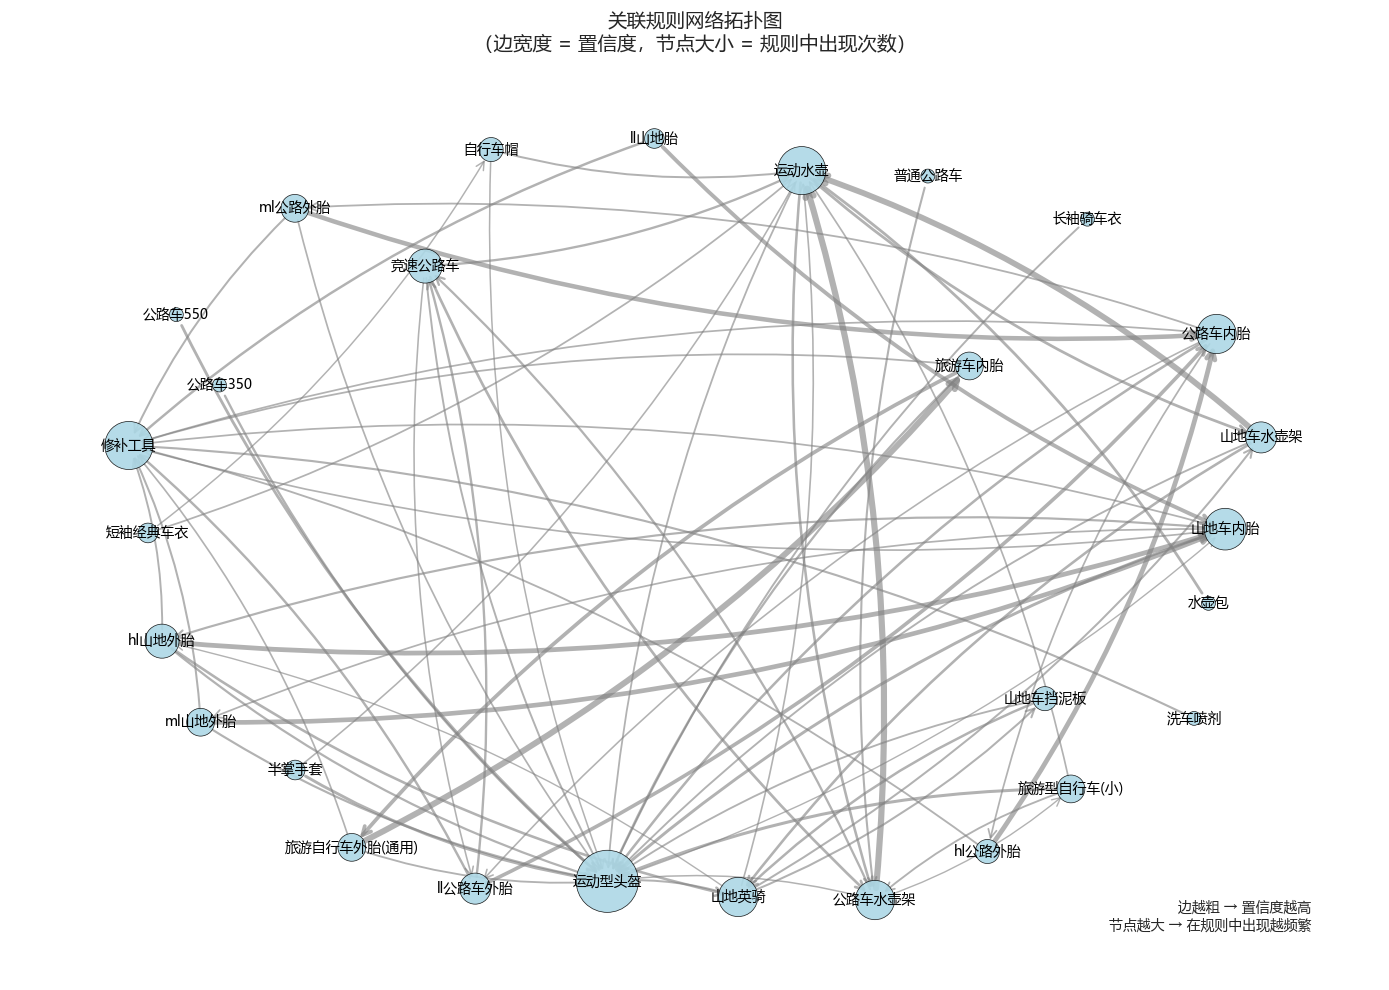

In [36]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# 设置中文字体（根据你的系统调整，此处使用常见黑体）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 假设你的 result 已经存在，且列名为：lhs, '', rhs, support, confidence, lift
# 为方便起见，我们重命名一下列，或者直接使用原列名
rules_df = result.copy()

# 将 frozenset 转换为字符串，以便在图中显示
rules_df['lhs_str'] = rules_df['lhs'].apply(lambda x: ', '.join(list(x)))
rules_df['rhs_str'] = rules_df['rhs'].apply(lambda x: ', '.join(list(x)))

# ------------------------------------------------------------
# 根据置信度或提升度筛选规则，避免图过于密集
# 例如保留置信度 > 0.2 或提升度 > 1.5 的规则
rules_df = rules_df[rules_df['confidence'] > 0.2]  # 取消注释以筛选
# ------------------------------------------------------------

# 构建有向图
G = nx.DiGraph()

# 统计每个商品在规则中出现的总次数（用于节点大小）
node_count = {}

# 添加边
for _, row in rules_df.iterrows():
    ant = row['lhs_str']
    con = row['rhs_str']
    # 使用置信度作为边的权重（也可用 lift 或 support）
    weight = row['confidence']

    G.add_edge(ant, con, weight=weight)

    # 更新节点计数
    node_count[ant] = node_count.get(ant, 0) + 1
    node_count[con] = node_count.get(con, 0) + 1

# ------------------------------------------------------------
# 如果没有节点（规则为空），提示并退出
if len(G.nodes) == 0:
    print("没有符合条件的规则，请调整筛选条件。")
    exit()

# 设置节点大小：出现次数越多节点越大
# 可以乘以一个系数使大小差异明显
node_sizes = [node_count[node] * 100 for node in G.nodes()]

# 设置边宽度：置信度越高边越粗
edge_widths = [G[u][v]['weight'] * 5 for u, v in G.edges()]

# ------------------------------------------------------------
# 绘制
plt.figure(figsize=(14, 10))

# 布局：spring_layout 适合展现聚类，k 控制节点间距
pos = nx.spring_layout(G, k=2, seed=42)

# 绘制节点
nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                       node_color='lightblue', alpha=0.9, edgecolors='black', linewidths=0.5)

# 绘制边（带箭头）
nx.draw_networkx_edges(G, pos, width=edge_widths,
                       edge_color='gray', alpha=0.6,
                       arrowstyle='->', arrowsize=15,
                       connectionstyle='arc3,rad=0.1')

# 绘制标签
nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif')

# 标题和说明
plt.title('关联规则网络拓扑图\n（边宽度 = 置信度，节点大小 = 规则中出现次数）', fontsize=14)
plt.text(0.95, 0.05, '边越粗 → 置信度越高\n节点越大 → 在规则中出现越频繁',
         transform=plt.gca().transAxes, ha='right', va='bottom',
         bbox=dict(facecolor='white', alpha=0.8))

plt.axis('off')
plt.tight_layout()
plt.show()

### 3.筛选互补品和互斥品

In [25]:
# 互补品
# lift提升度首先要大于1，然后再排序选择自己希望深究的前n个
hubu = result[result['lift']>1].sort_values(by = 'lift', ascending = False).head(5)

# 互斥品
huchi = result[result['lift']>1].sort_values(by = 'lift', ascending = False).head(5)

In [26]:
hubu

,lhs,,rhs,support,confidence,lift
71,(旅游自行车外胎(通用)),==>,(旅游车内胎),0.035662,0.860386,13.090553
70,(旅游车内胎),==>,(旅游自行车外胎(通用)),0.035662,0.542591,13.090553
93,(公路车内胎),==>,(hl公路外胎),0.025970,0.249097,6.585282
92,(hl公路外胎),==>,(公路车内胎),0.025970,0.686567,6.585282
66,(ml公路外胎),==>,(公路车内胎),0.027288,0.651685,6.250710


In [27]:
huchi

,lhs,,rhs,support,confidence,lift
71,(旅游自行车外胎(通用)),==>,(旅游车内胎),0.035662,0.860386,13.090553
70,(旅游车内胎),==>,(旅游自行车外胎(通用)),0.035662,0.542591,13.090553
93,(公路车内胎),==>,(hl公路外胎),0.025970,0.249097,6.585282
92,(hl公路外胎),==>,(公路车内胎),0.025970,0.686567,6.585282
66,(ml公路外胎),==>,(公路车内胎),0.027288,0.651685,6.250710


## 四、基于关联规则的智能推荐
### 10.5 推荐策略
#### 1. 目标：最高营销响应率（看可信度）
- 逻辑：优先推荐**买了A后最可能买B**的商品。

In [28]:
# 使用的是左手规则
# 使用frozenset来对自字典的键进行选择
purchase_good = result[result['lhs'] == frozenset({'山地英骑'})]
# 根据置信度排序
purchase_good.sort_values(by ='confidence',ascending = False)

,lhs,,rhs,support,confidence,lift
62,(山地英骑),==>,(山地车挡泥板),0.034345,0.294711,3.110273
94,(山地英骑),==>,(山地车水壶架),0.034110,0.292693,3.205144
72,(山地英骑),==>,(运动型头盔),0.033404,0.286637,0.987274
96,(山地英骑),==>,(运动水壶),0.027711,0.237788,1.239984
75,(山地英骑),==>,(hl山地外胎),0.023524,0.201857,3.223495
79,(山地英骑),==>,(山地车内胎),0.015573,0.133629,0.976717
36,(山地英骑),==>,(修补工具),0.015385,0.132015,0.932216


- 结论：优先推荐**山地车挡泥板**（可信度最高）。

#### 2. 目标：最大化销售额（看提升度）
- 逻辑：优先推荐**能最大幅度提升购买概率**的商品。

In [29]:
purchase_good.sort_values(by = 'lift', ascending = False)

,lhs,,rhs,support,confidence,lift
75,(山地英骑),==>,(hl山地外胎),0.023524,0.201857,3.223495
94,(山地英骑),==>,(山地车水壶架),0.034110,0.292693,3.205144
62,(山地英骑),==>,(山地车挡泥板),0.034345,0.294711,3.110273
96,(山地英骑),==>,(运动水壶),0.027711,0.237788,1.239984
72,(山地英骑),==>,(运动型头盔),0.033404,0.286637,0.987274
79,(山地英骑),==>,(山地车内胎),0.015573,0.133629,0.976717
36,(山地英骑),==>,(修补工具),0.015385,0.132015,0.932216


- 结论：优先推荐**hill山地外胎**（提升度最高）。

#### 3. 目标：用户未消费时的推荐（看右规则）
- 逻辑：筛选出**rhs为目标商品**的规则，按提升度排序，找到最适合搭配推荐的前置商品。

In [30]:
# 筛选出右手规则，并按照提升度降序排列
purchase_good = result[result['rhs']==frozenset({'山地英骑'})].sort_values('lift', ascending = False)
purchase_good

,lhs,,rhs,support,confidence,lift
76,(hl山地外胎),==>,(山地英骑),0.023524,0.375657,3.223495
95,(山地车水壶架),==>,(山地英骑),0.034110,0.373519,3.205144
63,(山地车挡泥板),==>,(山地英骑),0.034345,0.362463,3.110273
97,(运动水壶),==>,(山地英骑),0.027711,0.144504,1.239984
73,(运动型头盔),==>,(山地英骑),0.033404,0.115054,0.987274
80,(山地车内胎),==>,(山地英骑),0.015573,0.113824,0.976717
37,(修补工具),==>,(山地英骑),0.015385,0.108638,0.932216


- 结论：将“山地英骑”与**hl山地外胎**或**山地车水壶架**组合推荐，最易带动销售。


## 五、使用Apriori算法的注意事项
### 1. 正向与负向关联
- **正向关联**（lift>1）：用于商品搭配、套餐设计。
- **负向关联**（lift<1）：用于识别替代品，指导新品引进、旧品淘汰，或店铺空间规避（避免竞品相邻）。

### 2. 算法局限性
- **量化不足**：无法直接将关联规则映射到经济指标（如销售额、利润）。
- **线性局限**：只能发现单一变量间的简单关联，无法挖掘多变量复杂关系（如非线性）。
- **效率问题**：数据集或项集变大时，计算复杂度急剧上升，效率低下。
- **实践建议**：实验室探索性分析适用，实际业务中需结合协同过滤、深度学习等其他算法，实现更高效的智能推荐。


## 六、核心总结
1.  **关联规则 vs 相关系数**：相关系数只能说明“有关系”，而关联规则能明确“谁影响谁、影响多大”，更适合业务决策。
2.  **三度的选择**：
    - 支持度：保证规则有普遍性。
    - 可信度：保证规则有强度。
    - 提升度：保证推荐有价值（lift>1才推荐）。
3.  **Apriori全流程**：
    - 数据探索 → 生成购物篮 → 挖掘关联规则 → 筛选互补/互斥品 → 业务化推荐。
4.  **业务价值**：
    - 货架布局：互补品相邻，互斥品远离。
    - 智能推荐：根据不同业务目标（响应率/销售额）选择不同推荐策略。
    - 商品管理：识别替代品，优化商品结构。

---